# Figure 3 generation notebook

This notebook regenerates manuscript Figure 3 from the `FIG3.zip` data archive in the same folder. No synthetic or placeholder data are generated.


Saved /Users/serhiibahdasariants/Desktop/ANNet/FIGURES/DATA AND SCRIPTS/FIG3.svg


Saved /Users/serhiibahdasariants/Desktop/ANNet/FIGURES/DATA AND SCRIPTS/FIG3.pdf


Saved /Users/serhiibahdasariants/Desktop/ANNet/FIGURES/DATA AND SCRIPTS/FIG3.png


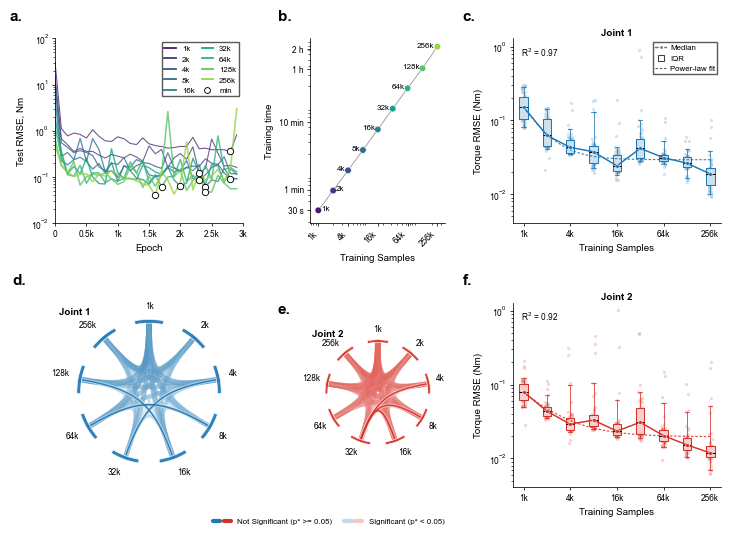

In [1]:
from pathlib import Path
import json
import zipfile

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D
from matplotlib.patches import PathPatch, Wedge
from matplotlib.path import Path as MplPath
from matplotlib.ticker import LogFormatterMathtext, LogLocator, NullFormatter
from matplotlib.legend_handler import HandlerTuple
from scipy.optimize import curve_fit

# -----------------------------------------------------------------------------
# Load data. FIG3.zip must be in the same folder as this notebook.
# -----------------------------------------------------------------------------
DATA_ARCHIVE = Path("FIG3.zip")
if not DATA_ARCHIVE.exists():
    DATA_ARCHIVE = Path("FIG3")
if not DATA_ARCHIVE.exists():
    raise FileNotFoundError(
        "Could not find FIG3.zip or FIG3 in the current folder. "
        "Place the data archive in the same folder as FIG3.ipynb."
    )

with zipfile.ZipFile(DATA_ARCHIVE) as archive:
    history = pd.read_csv(archive.open("fig3_test_rmse_history.csv"))
    train_history = pd.read_csv(archive.open("fig3_train_loss_history.csv"))
    training_times = pd.read_csv(archive.open("fig3_training_times.csv"))
    rmse_values = pd.read_csv(archive.open("fig3_rmse_values.csv"))
    best_checkpoints = pd.read_csv(archive.open("fig3_best_checkpoints.csv"))
    pairwise_statistics = pd.read_csv(archive.open("fig3_pairwise_statistics.csv"))
    metadata = json.load(archive.open("fig3_metadata.json"))

DATASET_SIZES = [int(v) for v in metadata["dataset_sizes"]]
ALPHA = 0.05

# -----------------------------------------------------------------------------
# Style and helper functions.
# -----------------------------------------------------------------------------
BLUE = "#1F77B4"
RED = "#D73027"
NEUTRAL = "#333333"
LIGHT_NEUTRAL = "#9A9A9A"

mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 7,
    "axes.labelsize": 7,
    "xtick.labelsize": 6,
    "ytick.labelsize": 6,
    "legend.fontsize": 5.7,
    "axes.linewidth": 0.55,
    "xtick.major.width": 0.55,
    "ytick.major.width": 0.55,
    "xtick.minor.width": 0.45,
    "ytick.minor.width": 0.45,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",
})

sample_size_palette = [
    "#440154", "#482878", "#3E4989", "#31688E", "#26828E",
    "#1F9E89", "#35B779", "#6DCD59", "#B4DE2C",
]
SIZE_CMAP = mpl.colors.LinearSegmentedColormap.from_list("sample_size_viridis", sample_size_palette)
SIZE_NORM = mpl.colors.LogNorm(vmin=min(DATASET_SIZES), vmax=max(DATASET_SIZES))


def size_color(size):
    return SIZE_CMAP(0.08 + 0.86 * float(SIZE_NORM(int(size))))


def format_sample_count(value):
    value = int(value)
    return f"{value // 1000}k" if value >= 1000 else str(value)


def format_epoch_tick(value):
    value = float(value)
    if value == 0:
        return "0"
    if value % 1000 == 0:
        return f"{int(value // 1000)}k"
    return f"{value / 1000:g}k"


def format_duration(seconds):
    seconds = float(seconds)
    if seconds < 60:
        return f"{int(round(seconds))} s"
    if seconds < 3600:
        return f"{seconds / 60:g} min"
    hours = seconds / 3600
    if abs(hours - round(hours)) < 0.02:
        return f"{int(round(hours))} h"
    return f"{hours:.1f} h"


def blend_with_white(color, amount):
    rgb = np.array(mcolors.to_rgb(color))
    return tuple(rgb * (1.0 - amount) + amount)


def style_open_axes(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(axis="both", which="major", direction="out", length=2.5, width=0.55, pad=2)
    ax.tick_params(axis="both", which="minor", direction="out", length=1.6, width=0.45)
    ax.grid(False)


def power_law_decay(x, a, b, c):
    return a * np.power(x, -b) + c


def calculate_r_squared(y_observed, y_predicted):
    rss = np.sum((y_observed - y_predicted) ** 2)
    tss = np.sum((y_observed - np.mean(y_observed)) ** 2)
    return np.nan if tss == 0 else 1.0 - rss / tss


def fit_power_law_to_medians(joint):
    medians = []
    valid_sizes = []
    for size in DATASET_SIZES:
        values = rmse_values.loc[
            (rmse_values["dataset_size"] == size) & (rmse_values["joint"] == joint),
            "torque_rmse_nm",
        ].to_numpy(dtype=float)
        if values.size == 0:
            continue
        valid_sizes.append(float(size))
        medians.append(float(np.median(values)))

    x = np.asarray(valid_sizes, dtype=float)
    y = np.asarray(medians, dtype=float)
    c0 = max(np.min(y) * 0.8, 0)
    a0 = max((np.max(y) - c0) * np.sqrt(np.min(x)), 1e-12)
    coeffs, _ = curve_fit(
        power_law_decay,
        x,
        y,
        p0=[a0, 0.5, c0],
        bounds=([0, 0, 0], [np.inf, np.inf, np.inf]),
        maxfev=10000,
    )
    r_squared = calculate_r_squared(y, power_law_decay(x, *coeffs))
    return x, y, coeffs, r_squared


def scale_inverse_p_values(adjusted_p_values, min_width=0.45, max_width=4.2):
    safe_p = np.clip(np.asarray(adjusted_p_values, dtype=float), np.finfo(float).tiny, 1.0)
    compressed_inverse_p = np.log10(1.0 / safe_p)
    if np.isclose(compressed_inverse_p.max(), compressed_inverse_p.min()):
        normalized = np.full_like(compressed_inverse_p, 0.5, dtype=float)
    else:
        low, high = np.percentile(compressed_inverse_p, [2, 98])
        if np.isclose(low, high):
            low, high = compressed_inverse_p.min(), compressed_inverse_p.max()
        normalized = np.clip((compressed_inverse_p - low) / (high - low), 0, 1)
    linewidth = min_width + normalized * (max_width - min_width)
    return normalized, linewidth


def chord_edges_for_joint(joint):
    df = pairwise_statistics[pairwise_statistics["joint"] == joint].copy()
    index_by_size = {size: idx for idx, size in enumerate(DATASET_SIZES)}
    df["source"] = df["dataset_size_a"].map(index_by_size)
    df["target"] = df["dataset_size_b"].map(index_by_size)
    df["adjusted_p"] = df["fdr_adjusted_p"].astype(float)
    df["is_significant"] = df["significant_fdr_0_05"].astype(bool)
    strength_norm, linewidth = scale_inverse_p_values(df["adjusted_p"].to_numpy())
    df["strength_norm"] = strength_norm
    df["linewidth"] = linewidth
    return df


def draw_pairwise_chord_diagram(ax, joint, title, base_color):
    edge_df = chord_edges_for_joint(joint)
    n = len(DATASET_SIZES)
    radius = 1.0
    label_radius = 1.18
    angles = np.linspace(np.pi / 2, np.pi / 2 - 2 * np.pi, n, endpoint=False)
    xy = np.column_stack((np.cos(angles), np.sin(angles))) * radius

    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_xlim(-1.35, 1.35)
    ax.set_ylim(-1.40, 1.30)

    significant_edges = edge_df[edge_df["is_significant"]].sort_values("linewidth", ascending=False)
    nonsignificant_edges = edge_df[~edge_df["is_significant"]].sort_values("linewidth", ascending=True)

    def draw_edge(row, color, alpha_value, zorder, linewidth_boost=0.0, control_scale=0.18):
        start = xy[int(row["source"])]
        end = xy[int(row["target"])]
        path = MplPath(
            [start, start * control_scale, end * control_scale, end],
            [MplPath.MOVETO, MplPath.CURVE4, MplPath.CURVE4, MplPath.CURVE4],
        )
        patch = PathPatch(
            path,
            facecolor="none",
            edgecolor=color,
            lw=float(row["linewidth"]) + linewidth_boost,
            alpha=alpha_value,
            capstyle="round",
            joinstyle="round",
            zorder=zorder,
            rasterized=False,
        )
        ax.add_patch(patch)

    for _, row in significant_edges.iterrows():
        color = blend_with_white(base_color, 0.62 - 0.42 * float(row["strength_norm"]))
        alpha_value = 0.22 + 0.40 * float(row["strength_norm"])
        draw_edge(row, color=color, alpha_value=alpha_value, zorder=1)

    for _, row in nonsignificant_edges.iterrows():
        draw_edge(row, color=blend_with_white(base_color, 0.72), alpha_value=0.82, zorder=3, linewidth_boost=2.0)
        draw_edge(row, color=base_color, alpha_value=0.92, zorder=4, linewidth_boost=0.55)

    node_span = 360 / n * 0.58
    for idx, angle in enumerate(angles):
        theta = np.degrees(angle)
        node = Wedge(
            (0, 0),
            1.055,
            theta - node_span / 2,
            theta + node_span / 2,
            width=0.055,
            facecolor=base_color,
            edgecolor="white",
            linewidth=0.5,
            alpha=0.92,
            zorder=6,
        )
        ax.add_patch(node)

        x_text = label_radius * np.cos(angle)
        y_text = label_radius * np.sin(angle)
        ha = "left" if x_text > 0.08 else "right" if x_text < -0.08 else "center"
        va = "bottom" if y_text > 0.08 else "top" if y_text < -0.08 else "center"
        ax.text(x_text, y_text, format_sample_count(DATASET_SIZES[idx]), ha=ha, va=va, fontsize=6, color="black", zorder=7)

    ax.text(-1.31, 1.16, title, ha="left", va="center", fontsize=7, fontweight="bold", color="black")


# -----------------------------------------------------------------------------
# Figure panels.
# -----------------------------------------------------------------------------
fig = plt.figure(figsize=(7.20, 5.25), constrained_layout=False)
gs = fig.add_gridspec(
    2,
    3,
    width_ratios=[1.28, 0.92, 1.42],
    height_ratios=[1.0, 1.0],
    wspace=0.38,
    hspace=0.43,
)
ax_a = fig.add_subplot(gs[0, 0])
ax_b = fig.add_subplot(gs[0, 1])
ax_c = fig.add_subplot(gs[0, 2])
ax_d = fig.add_subplot(gs[1, 0])
ax_e = fig.add_subplot(gs[1, 1])
ax_f = fig.add_subplot(gs[1, 2])

# a. Test RMSE during training.
for size in DATASET_SIZES:
    subset = history[history["dataset_size"] == size].sort_values("epoch")
    best = best_checkpoints[best_checkpoints["dataset_size"] == size].iloc[0]
    color = size_color(size)
    ax_a.plot(subset["epoch"], subset["test_rmse_nm"], color=color, linewidth=0.75 + 0.45 * float(SIZE_NORM(size)), alpha=0.78, zorder=2)
    ax_a.scatter([best["best_epoch"]], [best["best_test_rmse_nm"]], s=21, marker="o", facecolor="white", edgecolor="black", linewidth=0.65, zorder=7)

ax_a.set_yscale("log")
ax_a.set_xlim(0, 3000)
ax_a.set_ylim(1e-2, 1e2)
ax_a.set_xlabel("Epoch")
ax_a.set_ylabel("Test RMSE, Nm")
ax_a.set_xticks([0, 500, 1000, 1500, 2000, 2500, 3000])
ax_a.set_xticklabels([format_epoch_tick(v) for v in ax_a.get_xticks()])
ax_a.yaxis.set_major_locator(LogLocator(base=10, numticks=5))
ax_a.yaxis.set_major_formatter(LogFormatterMathtext(base=10))
ax_a.yaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10) * 0.1, numticks=12))
style_open_axes(ax_a)
legend_handles = [Line2D([0], [0], color=size_color(size), linewidth=1.3, label=format_sample_count(size)) for size in DATASET_SIZES]
legend_handles.append(Line2D([0], [0], marker="o", linestyle="None", markerfacecolor="white", markeredgecolor="black", markeredgewidth=0.65, markersize=4.2, label="min"))
ax_a.legend(handles=legend_handles, loc="upper right", frameon=True, fancybox=False, edgecolor="0.35", framealpha=1, ncol=2, handlelength=1.4, columnspacing=0.9, borderpad=0.35)

# b. Training time.
training_times = training_times.sort_values("dataset_size")
colors = [size_color(size) for size in training_times["dataset_size"]]
ax_b.plot(training_times["dataset_size"], training_times["elapsed_seconds"], color="0.62", linewidth=0.65, zorder=1)
ax_b.scatter(training_times["dataset_size"], training_times["elapsed_seconds"], c=colors, s=22, edgecolor="white", linewidth=0.35, zorder=3)
ax_b.set_xscale("log")
ax_b.set_yscale("log")
ax_b.set_xlim(min(DATASET_SIZES) / 1.45, max(DATASET_SIZES) * 1.45)
ax_b.set_ylim(training_times["elapsed_seconds"].min() / 1.55, training_times["elapsed_seconds"].max() * 1.32)
ax_b.set_xlabel("Training Samples")
ax_b.set_ylabel("Training time")
xticks_b = [1000, 4000, 16000, 64000, 256000]
ax_b.set_xticks(xticks_b)
ax_b.set_xticklabels([format_sample_count(v) for v in xticks_b], rotation=45, ha="right")
time_ticks = np.asarray([30, 60, 600, 3600, 7200], dtype=float)
ax_b.set_yticks(time_ticks)
ax_b.set_yticklabels([format_duration(v) for v in time_ticks])
ax_b.yaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10) * 0.1, numticks=12))
ax_b.yaxis.set_minor_formatter(NullFormatter())
for size, seconds in zip(training_times["dataset_size"], training_times["elapsed_seconds"]):
    if int(size) <= 2000:
        x_text, ha = size * 1.12, "left"
    else:
        x_text, ha = size * 0.88, "right"
    ax_b.text(x_text, seconds * 1.05, format_sample_count(size), fontsize=5.8, ha=ha, va="center", color="black")
style_open_axes(ax_b)

# c and f. Torque RMSE distributions.
positions = np.log10(np.asarray(DATASET_SIZES, dtype=float))
tick_sizes = [1000, 4000, 16000, 64000, 256000]
y_all = rmse_values["torque_rmse_nm"].to_numpy(dtype=float)
y_all = y_all[np.isfinite(y_all) & (y_all > 0)]
y_min = max(y_all.min() * 0.65, 1e-4)
y_max = y_all.max() * 1.25
rng = np.random.default_rng(23)


def draw_rmse_distribution_panel(ax, joint, color, title, show_ylabel=False):
    data_by_size = [
        rmse_values.loc[(rmse_values["dataset_size"] == size) & (rmse_values["joint"] == joint), "torque_rmse_nm"].to_numpy(dtype=float)
        for size in DATASET_SIZES
    ]
    for x_pos, values in zip(positions, data_by_size):
        jitter = rng.uniform(-0.026, 0.026, size=len(values))
        ax.scatter(np.full(len(values), x_pos) + jitter, values, s=5.5, color=blend_with_white(color, 0.28), alpha=0.28, linewidths=0, zorder=1, rasterized=False)

    box = ax.boxplot(
        data_by_size,
        positions=positions,
        widths=0.11,
        whis=(5, 95),
        showfliers=False,
        patch_artist=True,
        manage_ticks=False,
        medianprops={"color": "black", "linewidth": 0.75},
        whiskerprops={"color": color, "linewidth": 0.55},
        capprops={"color": color, "linewidth": 0.55},
    )
    for patch in box["boxes"]:
        patch.set_facecolor(blend_with_white(color, 0.78))
        patch.set_edgecolor(color)
        patch.set_linewidth(0.75)

    x_data, medians, coeffs, r2 = fit_power_law_to_medians(joint)
    ax.plot(np.log10(x_data), medians, color=color, linewidth=1.05, marker="o", markersize=2.7, markerfacecolor=color, markeredgecolor="white", markeredgewidth=0.35, zorder=4)
    x_fit = np.geomspace(min(DATASET_SIZES), max(DATASET_SIZES), 300)
    ax.plot(np.log10(x_fit), power_law_decay(x_fit, *coeffs), color=color, linewidth=0.8, linestyle=(0, (2.2, 1.6)), alpha=0.9, zorder=3)
    ax.text(0.04, 0.96, f"R$^2$ = {r2:.2f}", transform=ax.transAxes, ha="left", va="top", fontsize=6.0, color="black")

    ax.set_yscale("log")
    ax.set_xlim(positions.min() - 0.14, positions.max() + 0.14)
    ax.set_ylim(y_min, y_max)
    ax.set_xticks(np.log10(np.asarray(tick_sizes, dtype=float)))
    ax.set_xticklabels([format_sample_count(size) for size in tick_sizes])
    ax.set_xlabel("Training Samples")
    ax.set_title(title, fontsize=7, fontweight="bold", color="black", pad=2)
    if show_ylabel:
        ax.set_ylabel("Torque RMSE (Nm)")
    else:
        ax.set_ylabel("Torque RMSE (Nm)")
    style_open_axes(ax)


draw_rmse_distribution_panel(ax_c, "J1", BLUE, "Joint 1", show_ylabel=True)
draw_rmse_distribution_panel(ax_f, "J2", RED, "Joint 2", show_ylabel=True)
ax_c.legend(
    handles=[
        Line2D([0], [0], color="0.45", marker="o", markerfacecolor="0.45", markeredgecolor="white", linewidth=1.0, markersize=3.0, label="Median"),
        Line2D([0], [0], marker="s", linestyle="None", markerfacecolor="white", markeredgecolor="0.25", markeredgewidth=0.75, markersize=5.0, label="IQR"),
        Line2D([0], [0], color="0.35", linewidth=0.8, linestyle=(0, (2.2, 1.6)), label="Power-law fit"),
    ],
    loc="upper right",
    frameon=True,
    fancybox=False,
    edgecolor="0.35",
    framealpha=1,
    borderpad=0.25,
    handlelength=1.5,
    handletextpad=0.45,
)

# d and e. Pairwise chord diagrams.
draw_pairwise_chord_diagram(ax_d, "J1", "Joint 1", BLUE)
draw_pairwise_chord_diagram(ax_e, "J2", "Joint 2", RED)

# Panel labels.
for label, ax in zip(["a", "b", "c", "d", "e", "f"], [ax_a, ax_b, ax_c, ax_d, ax_e, ax_f]):
    ax.text(-0.24, 1.08, f"{label}.", transform=ax.transAxes, ha="left", va="bottom", fontsize=11, fontweight="bold", color="black")

# Chord significance legend at bottom.
not_sig_handles = (
    Line2D([0], [0], color=BLUE, linewidth=3.0, solid_capstyle="round"),
    Line2D([0], [0], color=RED, linewidth=3.0, solid_capstyle="round"),
)
sig_handles = (
    Line2D([0], [0], color=blend_with_white(BLUE, 0.72), linewidth=3.0, solid_capstyle="round"),
    Line2D([0], [0], color=blend_with_white(RED, 0.72), linewidth=3.0, solid_capstyle="round"),
)
fig.legend(
    handles=[not_sig_handles, sig_handles],
    labels=["Not Significant (p* >= 0.05)", "Significant (p* < 0.05)"],
    handler_map={tuple: HandlerTuple(ndivide=None)},
    loc="lower center",
    bbox_to_anchor=(0.44, 0.025),
    ncol=2,
    frameon=False,
    handlelength=2.3,
    columnspacing=1.5,
)

fig.subplots_adjust(left=0.06, right=0.985, top=0.965, bottom=0.11)

for ext in ("svg", "pdf", "png"):
    output_path = Path(f"FIG3.{ext}")
    if ext == "png":
        fig.savefig(output_path, dpi=600, bbox_inches="tight", pad_inches=0.03, facecolor="white")
    else:
        fig.savefig(output_path, bbox_inches="tight", pad_inches=0.03, facecolor="white")
    print(f"Saved {output_path.resolve()}")

plt.show()
